# Clase 4 — Sistema masa–resorte, vibración libre y respuesta forzada

## Fundamentos de Vibraciones

En esta clase estudiaremos un sistema vibratorio de un grado de libertad compuesto por una masa $m$, un resorte de rigidez $k$ y una fuerza externa $f(t)$.

El objetivo es conectar:

- el modelo físico,
- la ecuación diferencial de movimiento,
- la frecuencia natural,
- la respuesta temporal,
- el análisis en frecuencia mediante FFT,
- la respuesta forzada,
- y el fenómeno de resonancia.

## 1. Modelo físico

Consideramos el sistema masa–resorte:

$m\ddot{x}(t) + kx(t) = f(t)$

donde:

- $m$: masa $[kg]$
- $k$: rigidez del resorte $[N/m]$
- $x(t)$: desplazamiento de la masa $[m]$
- $f(t)$: fuerza externa aplicada $[N]$

Cuando no existe fuerza externa:

$
f(t)=0
$

el sistema queda en vibración libre:

$
m\ddot{x}(t)+kx(t)=0
$

In [1]:
# 1. Importar librerías

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq

## 2. Parámetros del sistema

La **frecuencia natural angular** del sistema no amortiguado se expresa como:

$
\omega_n = \sqrt{\frac{k}{m}}
$

donde $\omega_n$ se mide en:

$
\text{rad/s}
$

Esta magnitud indica qué tan rápido oscila el sistema en términos angulares.

Para expresar la frecuencia en ciclos por segundo, usamos la **frecuencia natural en Hertz**:

$
f_n = \frac{\omega_n}{2\pi}
$

donde $f_n$ se mide en:

$
\text{Hz}
$

El periodo natural del movimiento es:

$
T_n = \frac{1}{f_n}
$

donde $T_n$ se mide en segundos.

En resumen, $\omega_n$ y $f_n$ representan la misma frecuencia natural del sistema, pero expresada en unidades distintas: rad/s y Hz, respectivamente.

In [2]:
# 2. Definir parámetros físicos

m = 1.0       # masa [kg]
k = 100.0     # rigidez [N/m]

wn = np.sqrt(k / m)       # frecuencia natural angular [rad/s]
fn = wn / (2 * np.pi)     # frecuencia natural [Hz]
Tn = 1 / fn               # periodo natural [s]

print(f"Frecuencia natural angular wn = {wn:.3f} rad/s")
print(f"Frecuencia natural fn = {fn:.3f} Hz")
print(f"Periodo natural Tn = {Tn:.3f} s")

Frecuencia natural angular wn = 10.000 rad/s
Frecuencia natural fn = 1.592 Hz
Periodo natural Tn = 0.628 s


## 3. Vibración libre

Para vibración libre, la solución depende de las condiciones iniciales:

$
x(0)=x_0
$

$
\dot{x}(0)=v_0
$

La solución puede escribirse como:

$
x(t) = \frac{v_0}{\omega_n}\sin(\omega_n t) + x_0\cos(\omega_n t)
$

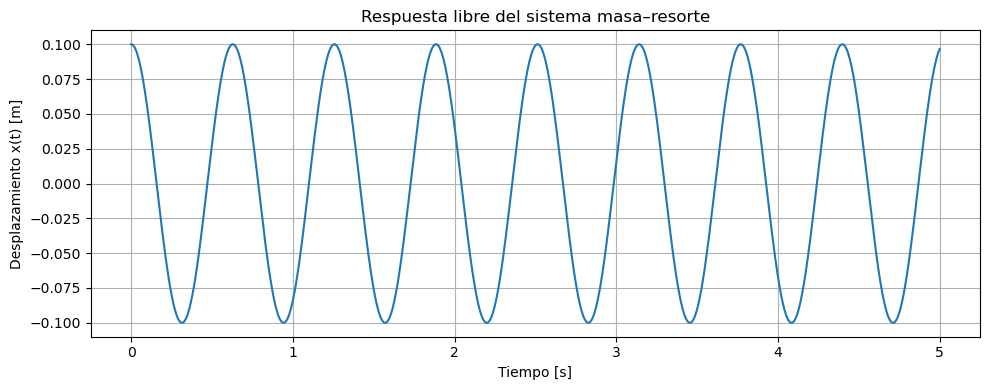

In [3]:
# 3. Respuesta libre analítica

x0 = 0.10     # desplazamiento inicial [m]
v0 = 0.00     # velocidad inicial [m/s]

t = np.linspace(0, 5, 3000)

x_libre = x0 * np.cos(wn * t) + (v0 / wn) * np.sin(wn * t)

plt.figure(figsize=(10, 4))
plt.plot(t, x_libre)
plt.title("Respuesta libre del sistema masa–resorte")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento x(t) [m]")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Identificación de frecuencia mediante FFT

La Transformada Rápida de Fourier (FFT) permite observar en qué frecuencia se concentra la energía de la señal.

Si el sistema oscila libremente, la frecuencia dominante debería coincidir con la frecuencia natural $f_n$.

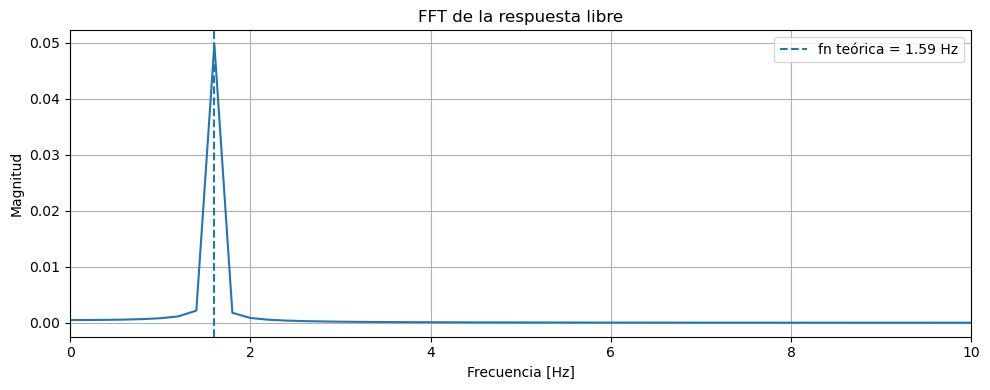

In [4]:
# 4. FFT de la respuesta libre

dt = t[1] - t[0]
N = len(t)

X = fft(x_libre)
freq = fftfreq(N, dt)

# Usar solo frecuencias positivas
mask = freq >= 0
freq_pos = freq[mask]
X_mag = np.abs(X[mask]) / N

plt.figure(figsize=(10, 4))
plt.plot(freq_pos, X_mag)
plt.axvline(fn, linestyle="--", label=f"fn teórica = {fn:.2f} Hz")
plt.title("FFT de la respuesta libre")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Respuesta forzada armónica

Ahora consideramos una fuerza externa armónica:

$
f(t)=F_0\sin(\omega t)
$

La ecuación de movimiento queda:

$
m\ddot{x}(t)+kx(t)=F_0\sin(\omega t)
$

Esta respuesta depende de la relación entre la frecuencia de excitación $\omega$ y la frecuencia natural $\omega_n$.

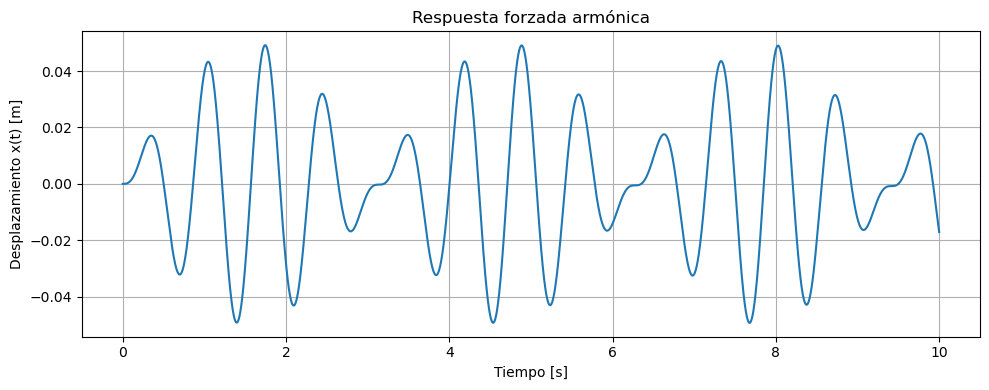

In [5]:
# 5. Respuesta forzada sin amortiguamiento

F0 = 1.0                # amplitud de fuerza [N]
omega_exc = 0.8 * wn    # frecuencia de excitación [rad/s]

def sistema_forzado(t, y):
    x = y[0]
    v = y[1]
    f_t = F0 * np.sin(omega_exc * t)
    a = (f_t - k * x) / m
    return [v, a]

t_eval = np.linspace(0, 10, 5000)
y0 = [0.0, 0.0]

sol = solve_ivp(
    sistema_forzado,
    t_span=(t_eval[0], t_eval[-1]),
    y0=y0,
    t_eval=t_eval
)

x_forzada = sol.y[0]

plt.figure(figsize=(10, 4))
plt.plot(t_eval, x_forzada)
plt.title("Respuesta forzada armónica")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento x(t) [m]")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Resonancia

Cuando la frecuencia de excitación se aproxima a la frecuencia natural:

$
\omega \approx \omega_n
$

la amplitud de la respuesta puede aumentar significativamente.

Este fenómeno se conoce como **resonancia**.

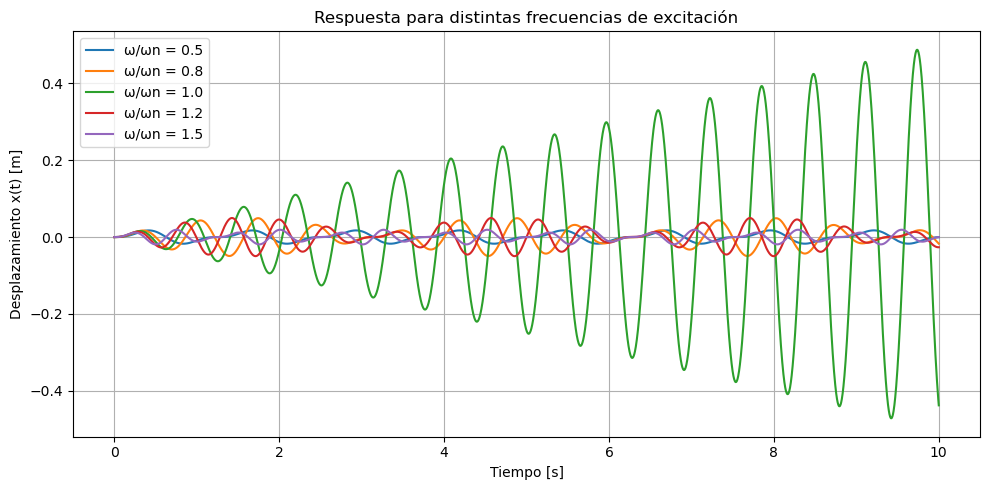

In [6]:
# 6. Comparar distintas frecuencias de excitación

frecuencias_relativas = [0.5, 0.8, 1.0, 1.2, 1.5]

plt.figure(figsize=(10, 5))

for r_val in frecuencias_relativas:
    omega_exc = r_val * wn

    def sistema(t, y):
        x = y[0]
        v = y[1]
        f_t = F0 * np.sin(omega_exc * t)
        a = (f_t - k * x) / m
        return [v, a]

    sol = solve_ivp(
        sistema,
        t_span=(0, 10),
        y0=[0.0, 0.0],
        t_eval=t_eval
    )

    plt.plot(t_eval, sol.y[0], label=f"ω/ωn = {r_val}")

plt.title("Respuesta para distintas frecuencias de excitación")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento x(t) [m]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Incorporando amortiguamiento

En un sistema real siempre existe algún nivel de disipación de energía. El modelo amortiguado se escribe como:

$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$

donde $c$ es el coeficiente de amortiguamiento.

También, se usa el factor de amortiguamiento:

$
\zeta = \frac{c}{2m\omega_n}
$

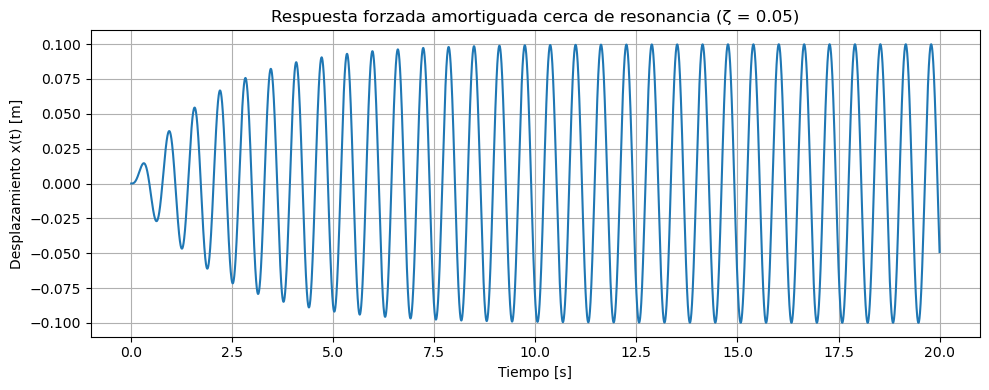

In [7]:
# 7. Respuesta forzada amortiguada

zeta = 0.05
c = 2 * zeta * m * wn

omega_exc = 1.0 * wn  # excitación cerca de resonancia

def sistema_amortiguado(t, y):
    x = y[0]
    v = y[1]
    f_t = F0 * np.sin(omega_exc * t)
    a = (f_t - c * v - k * x) / m
    return [v, a]

t_amort = np.linspace(0, 20, 8000)

sol = solve_ivp(
    sistema_amortiguado,
    t_span=(0, 20),
    y0=[0.0, 0.0],
    t_eval=t_amort
)

plt.figure(figsize=(10, 4))
plt.plot(sol.t, sol.y[0])
plt.title(f"Respuesta forzada amortiguada cerca de resonancia (ζ = {zeta})")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento x(t) [m]")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. De la ecuación diferencial al dominio de la frecuencia

Para estudiar la respuesta en frecuencia del sistema, utilizamos una propiedad fundamental de la Transformada de Fourier.

Si:

$
x(t) \longleftrightarrow X(\omega)
$

entonces:
$
\frac{dx(t)}{dt} \longleftrightarrow j\omega X(\omega)
$

y, por extensión:

$
\frac{d^2x(t)}{dt^2} \longleftrightarrow (j\omega)^2 X(\omega)
$

Como:

$
(j\omega)^2 = -\omega^2
$

se obtiene:

$
\ddot{x}(t) \longleftrightarrow -\omega^2 X(\omega)
$

## 9. Aplicación al sistema masa–resorte–amortiguador

Partimos de la ecuación de movimiento:

$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$

Aplicando Transformada de Fourier a ambos lados:

$m\mathcal{F}\{\ddot{x}(t)\} +
c\mathcal{F}\{\dot{x}(t)\} +
k\mathcal{F}\{x(t)\} =
\mathcal{F}\{f(t)\}$

usando las propiedades:

$
\mathcal{F}\{\dot{x}(t)\}=j\omega X(\omega)
$

$
\mathcal{F}\{\ddot{x}(t)\}=-\omega^2 X(\omega)
$

obtenemos:

$
m(-\omega^2)X(\omega)+c(j\omega)X(\omega)+kX(\omega)=F(\omega)
$

factorizando \(X(\omega)\):

$
\left(k-m\omega^2+jc\omega\right)X(\omega)=F(\omega)
$

por lo tanto:

$
\frac{X(\omega)}{F(\omega)}=
\frac{1}{k-m\omega^2+jc\omega}
$

La función:

$
H(\omega)=\frac{X(\omega)}{F(\omega)}
$

se denomina **función de respuesta en frecuencia**.

## 10. Forma adimensional de la respuesta en frecuencia

La función de respuesta en frecuencia es:

$
H(\omega)=\frac{1}{k-m\omega^2+jc\omega}
$

Su módulo es:

$
|H(\omega)|=
\frac{1}{\sqrt{(k-m\omega^2)^2+(c\omega)^2}}
$

Si definimos:

$
\omega_n=\sqrt{\frac{k}{m}}
$

$
r=\frac{\omega}{\omega_n}
$

$
\zeta=\frac{c}{2m\omega_n}
$

entonces la amplificación dinámica normalizada puede escribirse como:

$
M(r)=\frac{1}{\sqrt{(1-r^2)^2+(2\zeta r)^2}}
$

Esta expresión permite estudiar cómo cambia la amplitud de la respuesta cuando varía la frecuencia de excitación.

## La razón por la cual la función de respuesta en frecuencia es tan útil.

Esto se debe a que la función de respuesta en frecuencia convierte una ecuación diferencial, en una ecuación algebraica. En el tiempo tenemos derivadas; mientras que en frecuencia, las derivadas se transforman en multiplicaciones por $j\omega$.

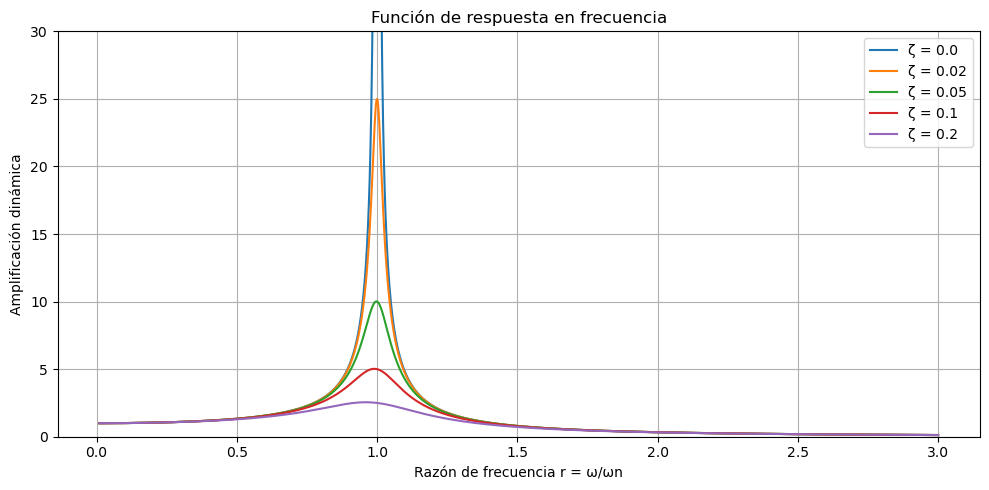

In [8]:
# 11. Curvas de respuesta en frecuencia

r = np.linspace(0.01, 3, 2000)
zetas = [0.00, 0.02, 0.05, 0.10, 0.20]

plt.figure(figsize=(10, 5))

for z in zetas:
    H = 1 / np.sqrt((1 - r**2)**2 + (2*z*r)**2)
    plt.plot(r, H, label=f"ζ = {z}")

plt.title("Función de respuesta en frecuencia")
plt.xlabel("Razón de frecuencia r = ω/ωn")
plt.ylabel("Amplificación dinámica")
plt.ylim(0, 30)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Preguntas para discusión

1. ¿Qué representa físicamente la frecuencia natural?
2. ¿Qué ocurre cuando la frecuencia de excitación se acerca a la frecuencia natural?
3. ¿Por qué el amortiguamiento reduce la amplitud máxima?
4. ¿Qué diferencia existe entre respuesta transitoria y respuesta estacionaria?
5. ¿Cómo se podría identificar la frecuencia natural a partir de una medición real?

## 13. Cierre de la clase

En esta clase conectamos el modelo físico de un sistema masa–resorte con su comportamiento dinámico.

Ideas clave:

- La frecuencia natural depende de $m$ y $k$.
- En vibración libre, el sistema oscila a su frecuencia natural.
- La FFT permite identificar la frecuencia dominante.
- En vibración forzada, la respuesta depende de la frecuencia de excitación.
- La resonancia ocurre cuando la excitación se aproxima a la frecuencia natural.
- El amortiguamiento limita la amplitud de la respuesta.